# Partition Visualization — RIPE Atlas Holdout Policies

Visualizes the K-fold anchor partition produced by `scripts/processing/ripe_atlas/stratify.py`
(driven by `scripts/processing/ripe_atlas/process_probes_and_anchors.smk`).

Set `PARTITION_PATH` below, then *Run All* to see:
1. Fold-size + label-balance summary
2. World map (anchors colored by fold)
3. Top-10 countries × fold
4. Top-N ASNs × fold
5. Intra-fold great-circle pairwise distance distribution

Default points at `datasets/ripe_atlas/asn_corpora/anchors/stratification.json`
(the canonical per-ASN VP corpus stratification). Re-point `PARTITION_PATH` /
`ANCHORS_FILE` for any other stratification artifact.

In [ ]:
# === Parameters (tagged) ===
PARTITION_PATH = "datasets/ripe_atlas/asn_corpora/anchors/stratification.json"
ANCHORS_FILE = "datasets/ripe_atlas/asn_corpora/anchors/anchors.json"


In [5]:
# Setup + load partition + anchor metadata
import json
import math
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Find repo root so the notebook works no matter where it's launched from.
ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
print(f"repo root: {ROOT}")

with open(ROOT / PARTITION_PATH) as fh:
    partition = json.load(fh)

with open(ROOT / ANCHORS_FILE) as fh:
    raw_entries = json.load(fh)

# Index anchor metadata by IP. reproducibility_anchors.json is anchors-only,
# so no is_anchor filter needed.
anchor_meta = {}
for e in raw_entries:
    ip = e.get("address_v4")
    geom = (e.get("geometry") or {}).get("coordinates")
    if not ip or not geom or len(geom) < 2:
        continue
    anchor_meta[ip] = {
        "lat": float(geom[1]),
        "lon": float(geom[0]),
        "country": e.get("country_code"),
        "asn": e.get("asn_v4"),
    }

fold_by_ip = partition["fold_assignments"]
K = partition["policy"]["k"]
print(f"policy: {partition["policy"]["class"]}")
print(f"  params: {partition["policy"]}")
print(f"corpus: {partition["corpus"]["n_anchors_yielded"]} anchors")
print(f"fold sizes: {partition["fold_sizes"]}")


repo root: /home/nuwinslab/workspace/atnt/cbg-framework
policy: DistGeoKFoldPolicy
  params: {'asn_bucket_top_n': 20, 'class': 'DistGeoKFoldPolicy', 'k': 5, 'kind': 'dist_geo_kfold', 'seed': 42}
corpus: 723 anchors
fold sizes: [145, 145, 145, 144, 144]


## 1) Fold-size + label-balance summary

In [6]:
# Build a single dataframe joining fold + metadata.
rows = []
for ip, f in fold_by_ip.items():
    m = anchor_meta.get(ip)
    if not m:
        continue
    rows.append({
        "ip": ip, "fold": int(f),
        "lat": m["lat"], "lon": m["lon"],
        "country": m["country"], "asn": m["asn"],
    })
df = pd.DataFrame(rows)
print(f"matched {len(df)}/{len(fold_by_ip)} anchors to metadata")

# Fold sizes (sanity check vs partition file)
print("\nAnchors per fold:")
print(df.groupby("fold").size().to_string())

# Country balance — top 10
top_countries = df["country"].value_counts().head(10).index.tolist()
country_tab = (
    df[df["country"].isin(top_countries)]
    .pivot_table(index="country", columns="fold", aggfunc="size", fill_value=0)
    .reindex(top_countries)
)
country_tab["spread"] = country_tab.max(axis=1) - country_tab.min(axis=1)
print("\nTop 10 countries × fold (max-min spread shown):")
print(country_tab)


matched 723/723 anchors to metadata

Anchors per fold:
fold
0    145
1    145
2    145
3    144
4    144

Top 10 countries × fold (max-min spread shown):
fold      0   1   2   3   4  spread
country                            
US       21  20  25  16  19       9
DE       19  19  23  20  18       5
NL        6   8  11   5  13       8
FR        5   6  11   9   8       6
GB        7   8   5   6   8       3
CH        6   6   4   6   5       2
SG        3   7   4   5   3       4
RU        5   1   5   3   5       4
IT        6   6   0   0   6       6
CA        3   3   1   6   4       5


## 2) World map: anchors colored by fold

/home/nuwinslab/workspace/atnt/cbg-framework/.venv/lib/python3.12/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/home/nuwinslab/workspace/atnt/cbg-framework/.venv/lib/python3.12/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/home/nuwinslab/workspace/atnt/cbg-framework/.venv/lib/python3.12/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/home/nuwinslab/workspace/atnt/cbg-framework/.venv/lib/python3.12/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0

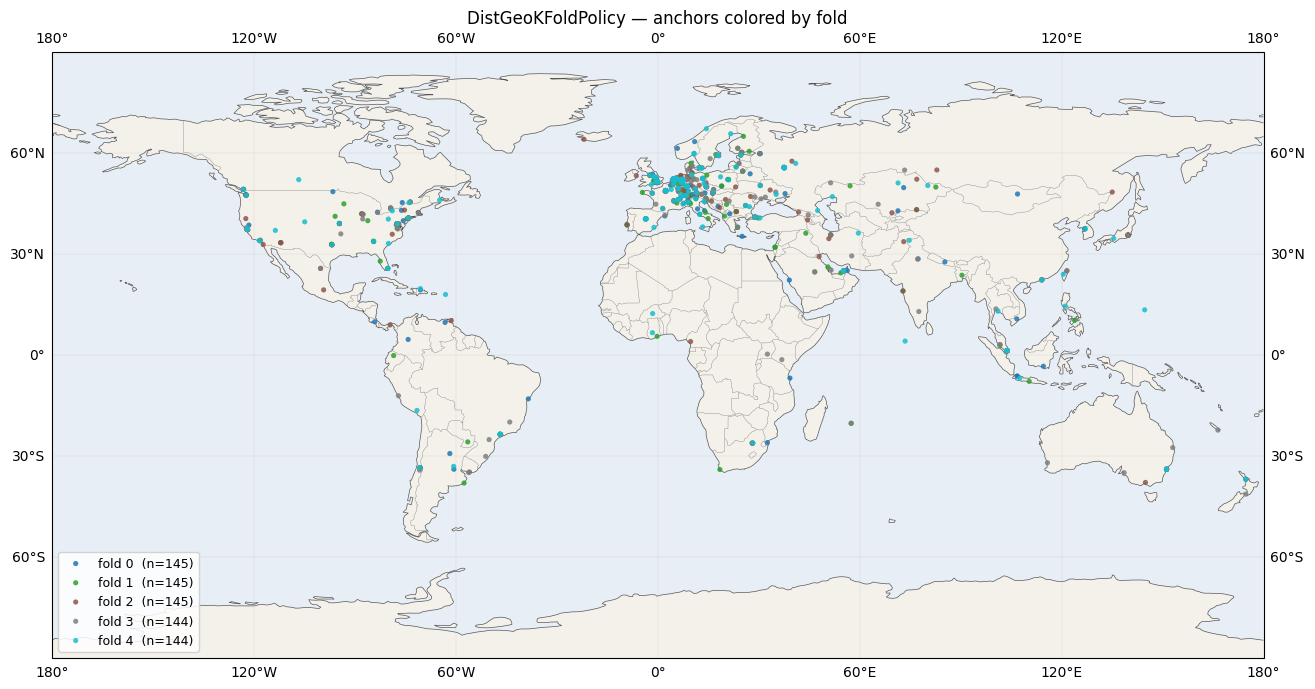

In [7]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

colors = plt.cm.tab10(np.linspace(0, 1, K))
fig = plt.figure(figsize=(14, 7))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, 90], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor="#f4f1ea")
ax.add_feature(cfeature.OCEAN, facecolor="#e8eef5")
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="#555")
ax.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor="#888")
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.4)
for f in range(K):
    sub = df[df["fold"] == f]
    ax.scatter(sub["lon"], sub["lat"], s=14, c=[colors[f]], alpha=0.85,
               edgecolors="none", label=f"fold {f}  (n={len(sub)})",
               transform=ccrs.PlateCarree(), zorder=3)
ax.set_title(f"{partition["policy"]["class"]} — anchors colored by fold")
ax.legend(loc="lower left", fontsize=9, framealpha=0.85)
plt.tight_layout()
plt.show()

## 3) Country composition × fold

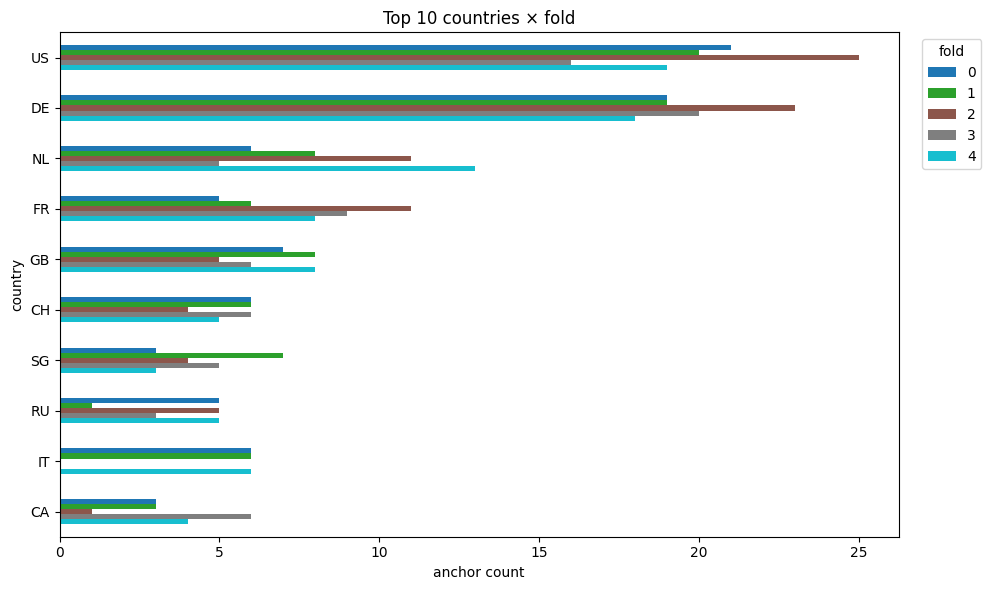

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
country_tab[list(range(K))].plot(
    kind="barh", stacked=False, ax=ax,
    color=[colors[f] for f in range(K)],
)
ax.set_xlabel("anchor count")
ax.set_ylabel("country")
ax.set_title("Top 10 countries × fold")
ax.legend(title="fold", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


## 4) ASN-bucket composition × fold

Top 22 buckets by total count (spread = max-min across folds):
fold          0    1    2    3    4  total  spread
asn_bucket                                        
other_AS    112  111  112  111  112    558       1
AS396982      3    4    4    3    4     18       1
AS20473       4    4    3    3    3     17       1
AS12008       4    3    3    3    3     16       1
AS202422      3    3    3    3    3     15       0
AS48503       2    2    2    2    3     11       1
AS31713       2    2    2    2    2     10       0
AS208722      1    1    1    2    2      7       1
AS42473       2    1    1    2    1      7       1
AS680         1    2    2    1    1      7       1
AS36236       2    1    1    1    2      7       1
AS14061       2    2    1    1    1      7       1
AS199610      2    1    1    1    1      6       1
AS55002       2    1    1    1    1      6       1
AS16276       2    0    1    1    2      6       2
AS202196      0    2    1    1    1      5       2
AS15133       0    

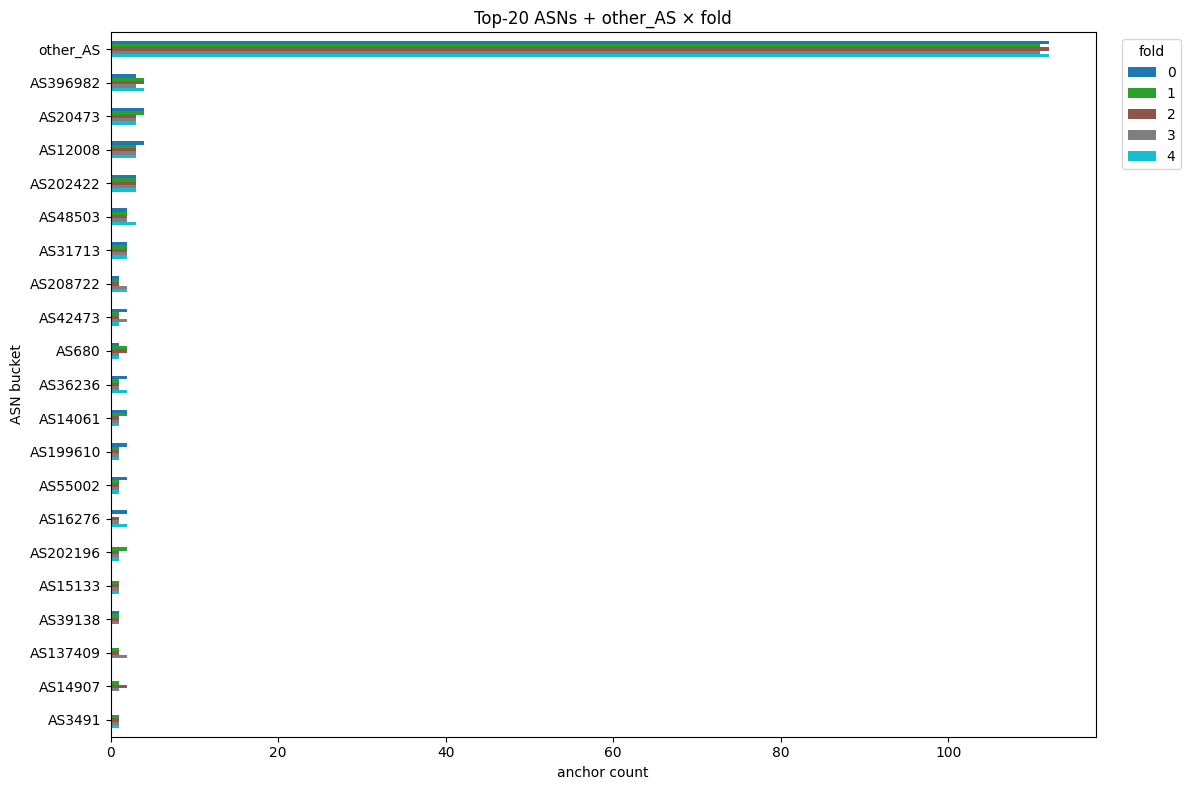

In [9]:
top_n = partition["policy"].get("asn_bucket_top_n", 20)
top_asns_list = [a for a, _ in df["asn"].value_counts().items() if a is not None][:top_n]

def bucket(asn):
    if asn is None:
        return "asn_none"
    if asn in top_asns_list:
        return f"AS{asn}"
    return "other_AS"

df["asn_bucket"] = df["asn"].map(bucket)
asn_tab = df.pivot_table(index="asn_bucket", columns="fold", aggfunc="size", fill_value=0)
asn_tab["total"] = asn_tab[list(range(K))].sum(axis=1)
asn_tab = asn_tab.sort_values("total", ascending=False)
asn_tab["spread"] = asn_tab[list(range(K))].max(axis=1) - asn_tab[list(range(K))].min(axis=1)
print(f"Top {top_n + 2} buckets by total count (spread = max-min across folds):")
print(asn_tab.head(top_n + 2))

fig, ax = plt.subplots(figsize=(12, 8))
asn_tab[list(range(K))].head(top_n + 2).plot(
    kind="barh", stacked=False, ax=ax,
    color=[colors[f] for f in range(K)],
)
ax.set_xlabel("anchor count")
ax.set_ylabel("ASN bucket")
ax.set_title(f"Top-{top_n} ASNs + other_AS × fold")
ax.legend(title="fold", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


## 5) Intra-fold great-circle pairwise distance distribution

How spatially spread is each fold? Mean & median pairwise great-circle
distance within each fold; higher values mean each fold spans more of the
globe (e.g. DistGeo round-robin), lower values mean tighter clusters
(e.g. spatial-blocked Sechidis).

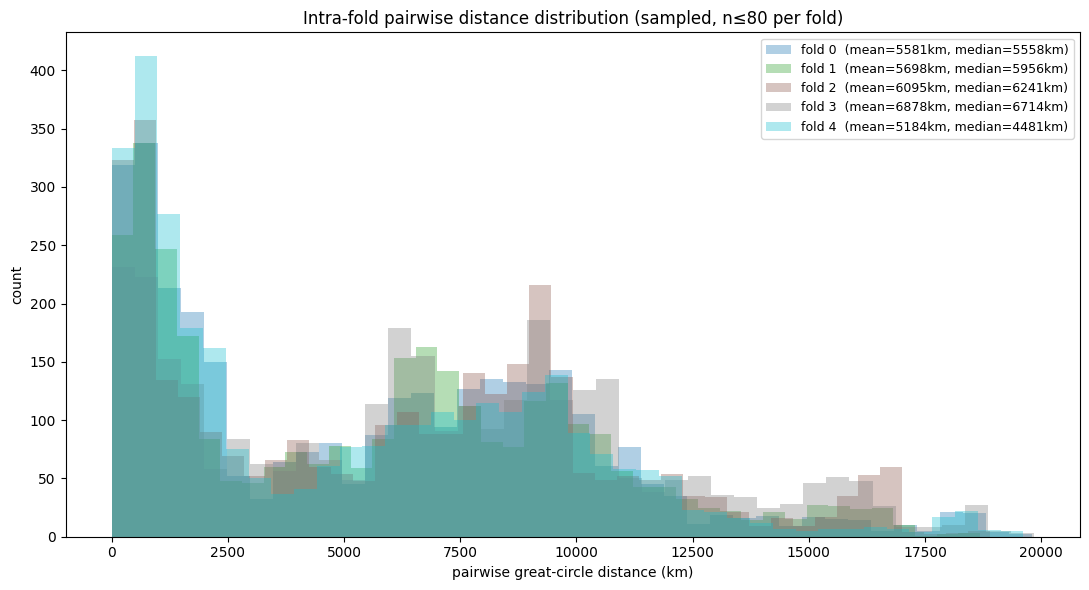


Intra-fold spread summary:
 fold   n     mean_km   median_km
    0 145 5581.398328 5557.862353
    1 145 5697.845807 5955.561340
    2 145 6095.445644 6241.493939
    3 144 6877.950509 6714.040326
    4 144 5184.160164 4481.277338


In [10]:
def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(math.radians, (lat1, lon1, lat2, lon2))
    dlat, dlon = lat2 - lat1, lon2 - lon1
    h = math.sin(dlat / 2) ** 2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon / 2) ** 2
    return 6367.0 * 2 * math.asin(math.sqrt(h))

def intra_fold_dists(fold_df, max_sample=80):
    sample = fold_df.sample(n=min(max_sample, len(fold_df)), random_state=42)
    pts = sample[["lat", "lon"]].to_numpy()
    return np.array([
        haversine_km(pts[i][0], pts[i][1], pts[j][0], pts[j][1])
        for i in range(len(pts)) for j in range(i + 1, len(pts))
    ])

fig, ax = plt.subplots(figsize=(11, 6))
summary = []
for f in range(K):
    sub_df = df[df["fold"] == f]
    dists = intra_fold_dists(sub_df, max_sample=80)
    ax.hist(dists, bins=40, alpha=0.35, color=colors[f],
            label=f"fold {f}  (mean={dists.mean():.0f}km, median={np.median(dists):.0f}km)")
    summary.append({"fold": f, "n": len(sub_df), "mean_km": dists.mean(),
                    "median_km": float(np.median(dists))})
ax.set_xlabel("pairwise great-circle distance (km)")
ax.set_ylabel("count")
ax.set_title("Intra-fold pairwise distance distribution (sampled, n≤80 per fold)")
ax.legend(fontsize=9, loc="upper right")
plt.tight_layout()
plt.show()

print("\nIntra-fold spread summary:")
print(pd.DataFrame(summary).to_string(index=False))
